<Axes: ylabel='Frequency'>

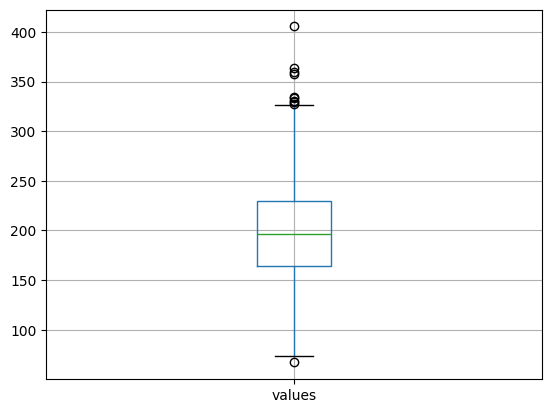

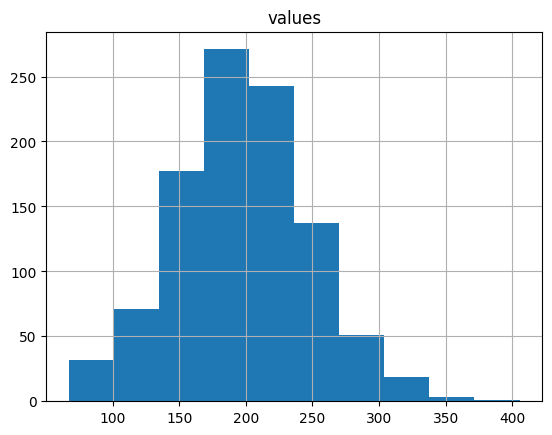

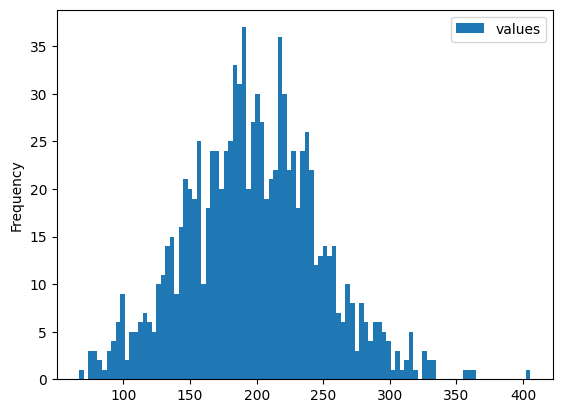

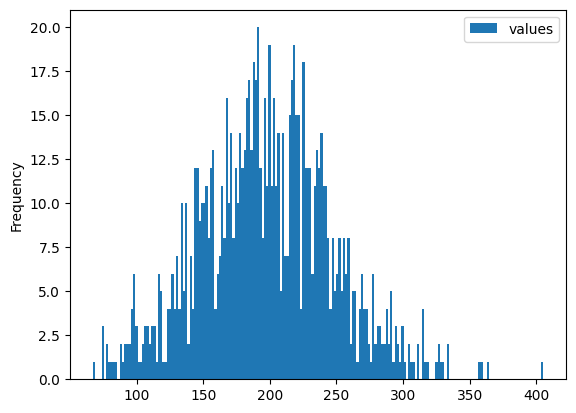

In [3]:
import pandas as pd
import numpy as np

np.random.seed(2)

data=np.random.normal(loc=200,scale=50,size=1000)

outliers=np.random.normal(loc=200,scale=50,size=5)
data=np.concatenate([data,outliers])

np.random.shuffle(data)

outliers_df=pd.DataFrame({'values':data})
outliers_df.boxplot()
outliers_df.hist()
outliers_df.plot.hist(bins=100)
outliers_df.plot.hist(bins=200)

/tmp/ipykernel_1187/3670823770.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cleaned_df= cleaned_df[(outliers_df['values']<=upper_bound)]


<Axes: >

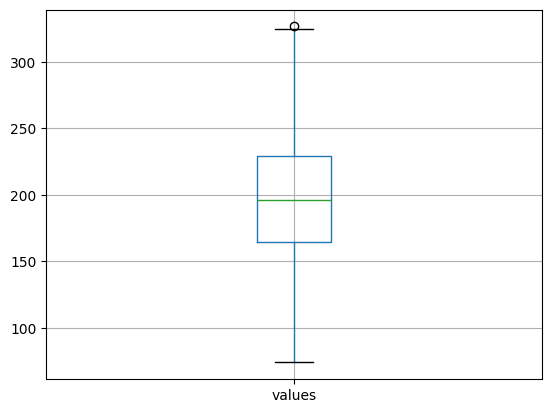

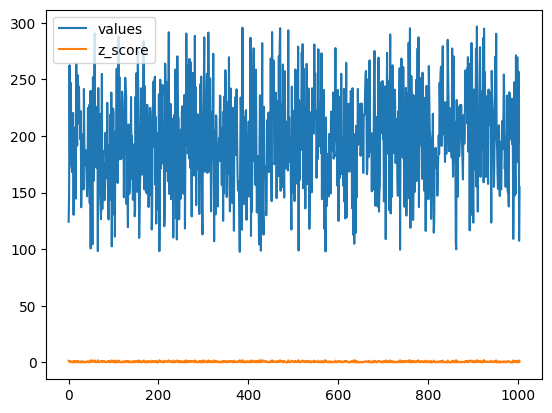

In [21]:
z_score=np.abs((outliers_df['values']-outliers_df['values'].mean())/outliers_df['values'].std())

outliers_df['z_score']=z_score
outliers_df['values'].mean()

q1=outliers_df['values'].quantile(0.25)
q3=outliers_df['values'].quantile(0.75)

IQR=q3-q1

lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR

cleaned_df= outliers_df[(outliers_df['values']>=lower_bound)]
cleaned_df= cleaned_df[(outliers_df['values']<=upper_bound)]

values= cleaned_df[['values']]

values.boxplot()

threshold=2

cleaned_df=outliers_df[outliers_df['z_score']<=threshold]
cleaned_df.plot()
